In [19]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, BertTokenizerFast, DistilBertTokenizerFast, AutoTokenizer
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import os
import shap
import spacy
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

In [2]:
nlp = spacy.load("en_core_web_sm")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [5]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df = pd.read_csv('../data/combined_letters_degendered.csv')

# Create Training and Test Sets

In [6]:
train_text, temp_text, train_labels, temp_labels = train_test_split(df['full_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

In [7]:
bert = AutoModel.from_pretrained("distilbert/distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

In [9]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

<ipython-input-9-40b617136a1e>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids'])
<ipython-input-9-40b617136a1e>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask'])
<ipython-input-9-40b617136a1e>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val['input_ids'])
<ipython-input-9-40b617136a1e>:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTe

In [20]:
batch_size = 16
train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_seq, val_mask, val_y)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

In [21]:
# freeze weights, uncomment if you would like to unfreeze weights
for param in bert.parameters():
    param.requires_grad = False


In [22]:
# Unfreeze top 2 layers to start (layers 4 and 5)
for i in [4, 5]:
    for param in bert.transformer.layer[i].parameters():
        param.requires_grad = True


# Create Model

In [23]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):

        super(BERT_Arch, self).__init__()

        self.bert = bert

        # dropout layer
        self.dropout = nn.Dropout(0.1)

        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(bert.config.hidden_size,128)

        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(128,2)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):

        #pass the inputs to the model
        distilbert_output = self.bert(sent_id, attention_mask=mask)

        hidden_state = distilbert_output[0]  # (bs, seq_len, dim)
        pooled_output = hidden_state[:, 0]

        x = self.fc1(pooled_output)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)

        # apply softmax activation
        x = self.softmax(x)

        return x

In [24]:
model = BERT_Arch(bert)
model = model.to(device)

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights= torch.tensor(class_weights, dtype=torch.float)
weights = weights.to(device)
cross_entropy  = nn.NLLLoss(weight=weights)
epochs = 10

In [26]:
# function to train the model
def train():

  model.train()

  total_loss, total_accuracy = 0, 0

  # empty list to save model predictions
  total_preds=[]
  total_labels=[]


  # Gradual unfreezing for layers 3 → 0 every 2 epochs starting at epoch 2
  layers_to_unfreeze = [3, 2, 1, 0]  # already started with 5 & 4 unfrozen

  # Compute how many new layers to unfreeze so far (0 at epoch 0–1, 1 at epoch 2–3, etc.)
  # layer_unfreeze_index = (epoch - 2) // 2

  # if 0 <= layer_unfreeze_index < len(layers_to_unfreeze):
  #     layer_idx = layers_to_unfreeze[layer_unfreeze_index]
  #     for param in model.bert.transformer.layer[layer_idx].parameters():
  #         param.requires_grad = True
  #     print(f"Epoch {epoch}: Unfroze DistilBERT layer {layer_idx}")


  # iterate over batches
  for step,batch in enumerate(tqdm(train_dataloader, desc="Training", leave=True)):

    # # progress update after every 50 batches.
    # if step % 50 == 0 and not step == 0:
    #   print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

    # push the batch to gpu
    batch = [r.to(device) for r in batch]

    sent_id, mask, labels = batch

    # clear previously calculated gradients
    model.zero_grad()

    # get model predictions for the current batch
    preds = model(sent_id, mask)

    # compute the loss between actual and predicted values
    loss = cross_entropy(preds, labels)

    # add on to the total loss
    total_loss = total_loss + loss.item()

    # backward pass to calculate the gradients
    loss.backward()

    # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # update parameters
    optimizer.step()

    # model predictions are stored on GPU. So, push it to CPU
    preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    labels=labels.detach().cpu().numpy()

    # append labels
    total_labels.append(labels)

  # compute the training loss of the epoch
  avg_loss = total_loss / len(train_dataloader)

  # predictions are in the form of (no. of batches, size of batch, no. of classes).
  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Training Classification Report: \n', classification_report(total_labels, epoch_preds))
  print('Training Confusion Matrix: \n', confusion_matrix(total_labels, epoch_preds))

  #returns the loss and predictions
  return avg_loss, total_preds

In [27]:
# function for evaluating the model
def evaluate():

  print("\nEvaluating...")

  # deactivate dropout layers
  model.eval()

  total_loss, total_accuracy = 0, 0

  # empty list to save the model predictions
  total_preds = []
  total_labels = []

  # iterate over batches
  for step,batch in enumerate(val_dataloader):

    # # Progress update every 50 batches.
    # if step % 50 == 0 and not step == 0:

    #   # Calculate elapsed time in minutes.
    #   elapsed = format_time(time.time() - t0)

    #   # Report progress.
    #   print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader)))

    # push the batch to gpu
    batch = [t.to(device) for t in batch]

    sent_id, mask, labels = batch

    # deactivate autograd
    with torch.no_grad():

      # model predictions
      preds = model(sent_id, mask)

      # compute the validation loss between actual and predicted values
      loss = cross_entropy(preds,labels)

      total_loss = total_loss + loss.item()

      preds = preds.detach().cpu().numpy()

      total_preds.append(preds)

      labels = labels.detach().cpu().numpy()

      total_labels.append(labels)

  # compute the validation loss of the epoch
  avg_loss = total_loss / len(val_dataloader)

  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Validation Classification Report: \n', classification_report(total_labels, epoch_preds))
  print('Validation Confusion Matrix: \n', confusion_matrix(total_labels, epoch_preds))

  return avg_loss, (epoch_preds, total_labels)

In [28]:
# set initial loss to infinite
# best_valid_loss = float('inf')
best_macro_f1 = 0.0

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]
macro_f1_scores = []

#for each epoch
for epoch in tqdm(range(epochs), desc="Training"):

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

    #train model
    train_loss, _ = train()

    #evaluate model
    valid_loss, (all_preds, all_labels) = evaluate()

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    macro_f1_scores.append(macro_f1)

    # Save the best model based on F1 score
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        print('Model Saved (best F1)!')
        torch.save(model, '../saved_models/saved_model.pt')

    # #save the best model
    # if valid_loss < best_valid_loss:
    #     best_valid_loss = valid_loss
    #     print('Model Saved!')
    #     torch.save(model, '../saved_models/saved_model.pt')

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')

Training:   0%|          | 0/10 [00:00<?, ?it/s]


 Epoch 1 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.32      0.45      0.38      2229
           1       0.70      0.58      0.64      4960

    accuracy                           0.54      7189
   macro avg       0.51      0.51      0.51      7189
weighted avg       0.58      0.54      0.56      7189

Training Confusion Matrix: 
 [[1000 1229]
 [2077 2883]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.34      0.55      0.42       278
           1       0.73      0.53      0.61       621

    accuracy                           0.54       899
   macro avg       0.54      0.54      0.52       899
weighted avg       0.61      0.54      0.55       899

Validation Confusion Matrix: 
 [[154 124]
 [293 328]]
Model Saved (best F1)!

Training Loss: 0.693
Validation Loss: 0.689

 Epoch 2 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

...

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.53      0.69      0.60      2229
           1       0.84      0.73      0.78      4960

    accuracy                           0.72      7189
   macro avg       0.69      0.71      0.69      7189
weighted avg       0.74      0.72      0.72      7189

Training Confusion Matrix: 
 [[1536  693]
 [1347 3613]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.38      0.58      0.46       278
           1       0.75      0.57      0.65       621

    accuracy                           0.57       899
   macro avg       0.56      0.57      0.55       899
weighted avg       0.64      0.57      0.59       899

Validation Confusion Matrix: 
 [[162 116]
 [270 351]]

Training Loss: 0.570
Validation Loss: 0.719

 Epoch 9 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.55      0.71      0.62      2229
           1       0.85      0.74      0.79      4960

    accuracy                           0.73      7189
   macro avg       0.70      0.73      0.71      7189
weighted avg       0.76      0.73      0.74      7189

Training Confusion Matrix: 
 [[1584  645]
 [1283 3677]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.38      0.46      0.42       278
           1       0.73      0.67      0.70       621

    accuracy                           0.61       899
   macro avg       0.56      0.56      0.56       899
weighted avg       0.63      0.61      0.61       899

Validation Confusion Matrix: 
 [[127 151]
 [203 418]]

Training Loss: 0.544
Validation Loss: 0.745

 Epoch 10 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.59      0.73      0.65      2229
           1       0.86      0.77      0.81      4960

    accuracy                           0.76      7189
   macro avg       0.72      0.75      0.73      7189
weighted avg       0.78      0.76      0.76      7189

Training Confusion Matrix: 
 [[1622  607]
 [1142 3818]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.36      0.63      0.46       278
           1       0.75      0.51      0.61       621

    accuracy                           0.55       899
   macro avg       0.56      0.57      0.53       899
weighted avg       0.63      0.55      0.56       899

Validation Confusion Matrix: 
 [[174 104]
 [304 317]]

Training Loss: 0.507
Validation Loss: 0.765


# Test Model

In [29]:
model = torch.load('../saved_models/saved_model.pt', weights_only=False)

In [30]:
model.eval()  # Set model to eval mode

# Create DataLoader for test set
test_data = TensorDataset(test_seq, test_mask, test_y)
test_dataloader = DataLoader(test_data, batch_size=32)  # adjust batch size as needed

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        sent_id, mask, labels = [b.to(device) for b in batch]

        # Forward pass
        outputs = model(sent_id, mask)  # shape: (batch_size, num_classes)

        # Get predicted class (as indices)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [31]:
  print('Test Classification Report: \n', classification_report(all_labels, all_preds))
  print('Test Confusion Matrix: \n', confusion_matrix(all_labels, all_preds))

Test Classification Report: 
               precision    recall  f1-score   support

           0       0.48      0.39      0.43       279
           1       0.75      0.81      0.78       620

    accuracy                           0.68       899
   macro avg       0.61      0.60      0.60       899
weighted avg       0.66      0.68      0.67       899

Test Confusion Matrix: 
 [[108 171]
 [118 502]]


# SHAP

In [32]:
def f(x):
    encoded_inputs = [tokenizer.encode_plus(v, padding="max_length", truncation=True, return_tensors="pt") for v in x]

    input_ids = torch.cat([e['input_ids'] for e in encoded_inputs], dim=0).to(device)
    attention_masks = torch.cat([e['attention_mask'] for e in encoded_inputs], dim=0).to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_masks)
        probs = torch.exp(logits).cpu().numpy()

    return probs[:, 1]  # probability of class 1


In [33]:
tokenizer.bos_token = tokenizer.cls_token
tokenizer.eos_token = tokenizer.sep_token

def truncating_tokenizer(texts):
    return tokenizer(texts, padding="max_length", truncation=True, max_length=512, return_tensors="pt")

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)

In [34]:
sample_texts = (
    test_text.dropna()                      # Remove NaNs
    .astype(str)                            # Convert everything to string
    .sample(100, random_state=42)            # Sample
    .tolist()                               # Convert to list
)

In [35]:
shap_values = explainer(sample_texts, fixed_context=1)

Token indices sequence length is longer than the specified maximum sequence length for this model (698 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 3/100 [00:22<07:23,  4.57s/it]

...

PartitionExplainer explainer:  99%|█████████▉| 99/100 [15:09<00:08,  8.93s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [15:19<00:00,  9.36s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [15:28,  9.29s/it]


In [36]:
# shap.plots.text(shap_values[2])

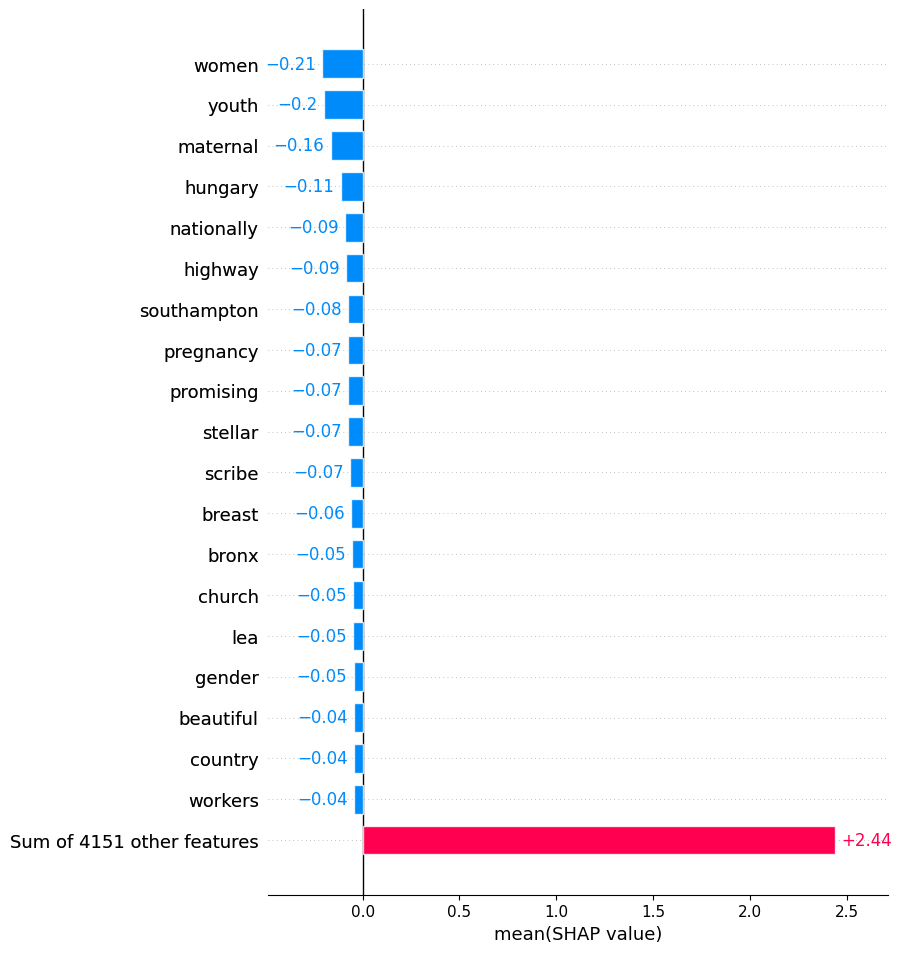

In [37]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort, max_display=20)

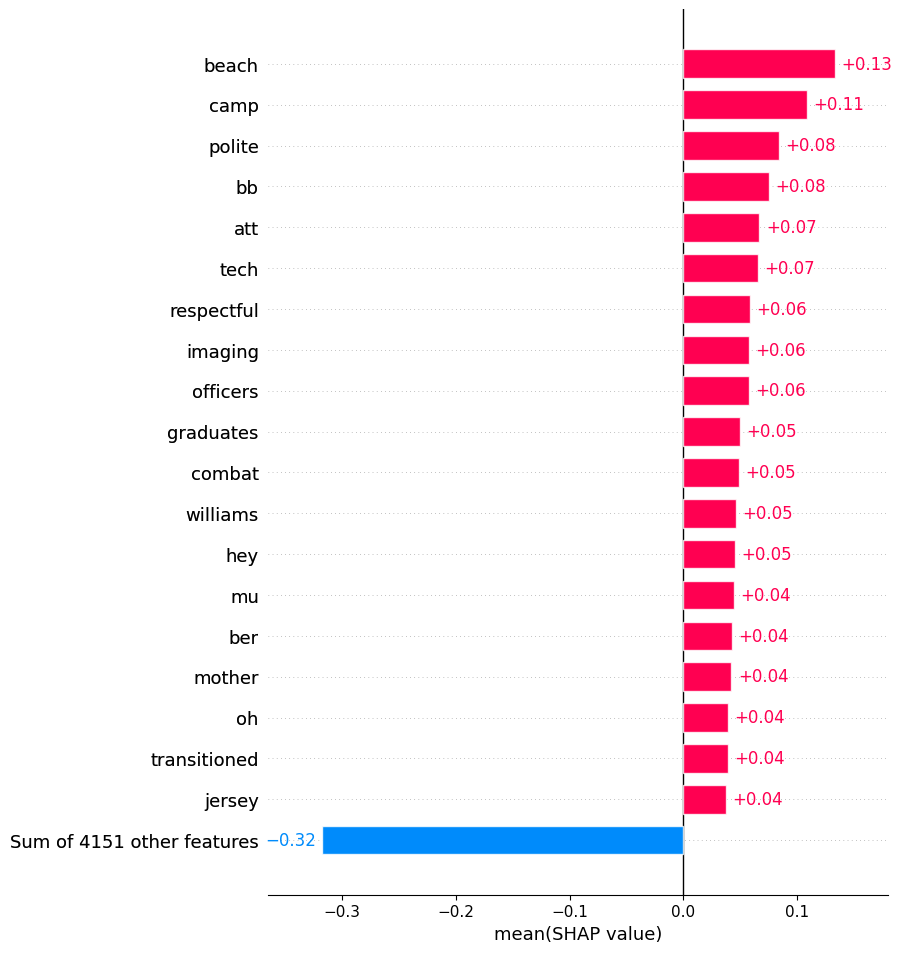

In [38]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort[::-1], max_display=20)

# POS Analysis

In [39]:
shap_text = shap_values[0]
tokens = shap_text.data
scores = shap_text.values

In [40]:
docs = list(nlp.pipe(tokens))

In [41]:
shap_pos_dict = defaultdict(list)
for doc, shap_score in zip(docs, scores):
    if len(doc) == 0:
        continue  # skip empty docs

    tok = doc[0]
    if not tok.is_stop and tok.is_alpha and tok.pos_ != "PUNCT":
        key = (tok.lemma_.lower(), tok.pos_)
        shap_pos_dict[key].append(shap_score)

# Step 2: Average SHAP values per (lemma, POS)
shap_pos_data = [(tok, sum(vals)/len(vals), pos) for (tok, pos), vals in shap_pos_dict.items()]

In [42]:
df_shap = pd.DataFrame(shap_pos_data, columns=["token", "shap_value", "pos"])
df_shap["direction"] = df_shap["shap_value"].apply(lambda x: "Male" if x > 0 else "Female")

In [43]:
def plot_top_shap_by_pos(df, pos_tag, top_n=10):
    subset = df[df["pos"] == pos_tag]

    # Get top N positive and negative
    top_pos = subset.sort_values("shap_value", ascending=False).head(top_n)
    top_neg = subset.sort_values("shap_value", ascending=True).head(top_n)

    # Combine and plot
    top = pd.concat([top_neg, top_pos])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x="shap_value",
        y="token",
        hue="direction",
        dodge=False,
        palette={"Male": "indianred", "Female": "steelblue"}
    )
    plt.title(f"Top SHAP Tokens for POS = {pos_tag}")
    plt.xlabel("Mean SHAP Value")
    plt.ylabel("Token")
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()


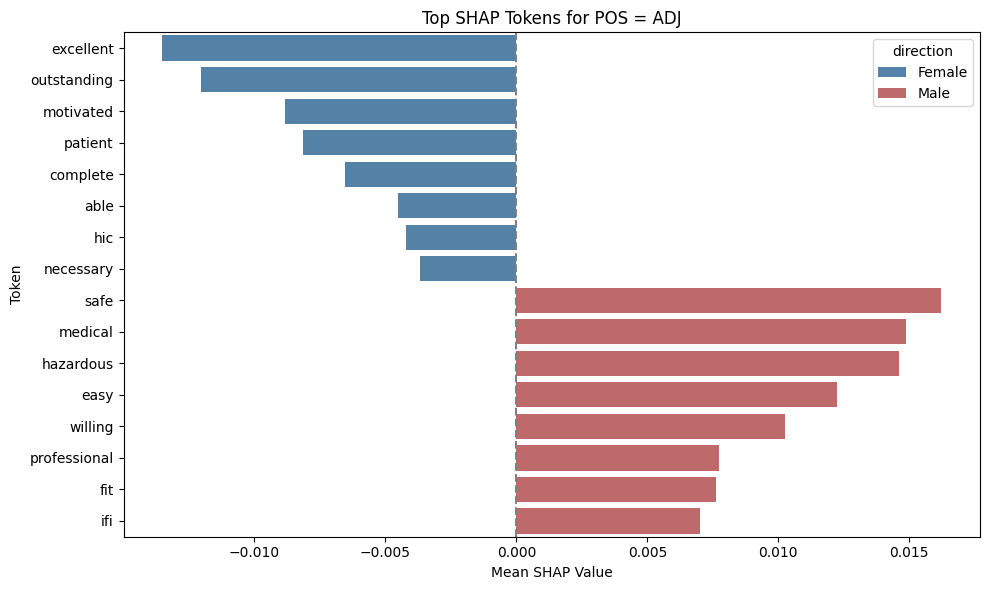

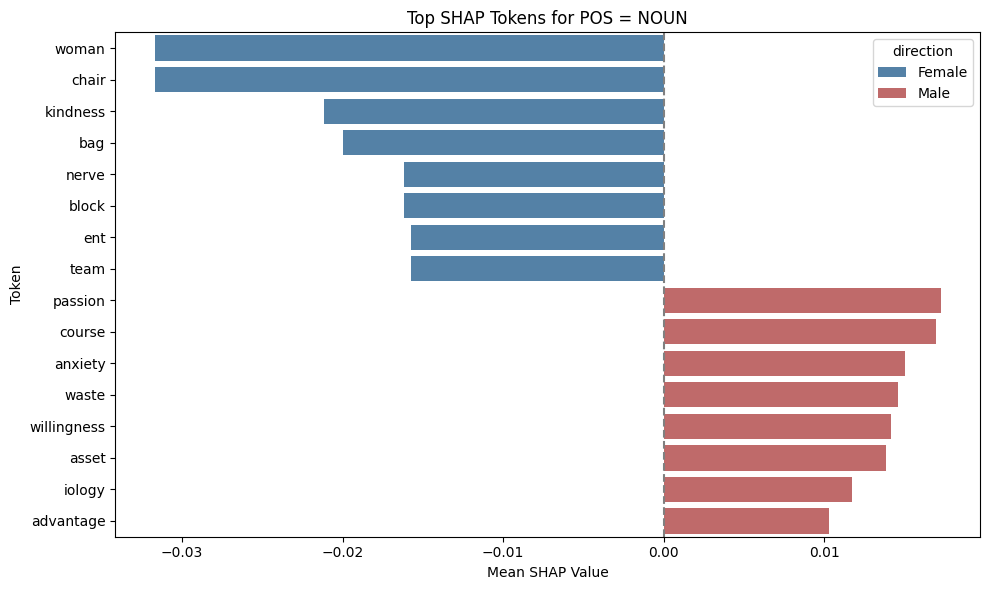

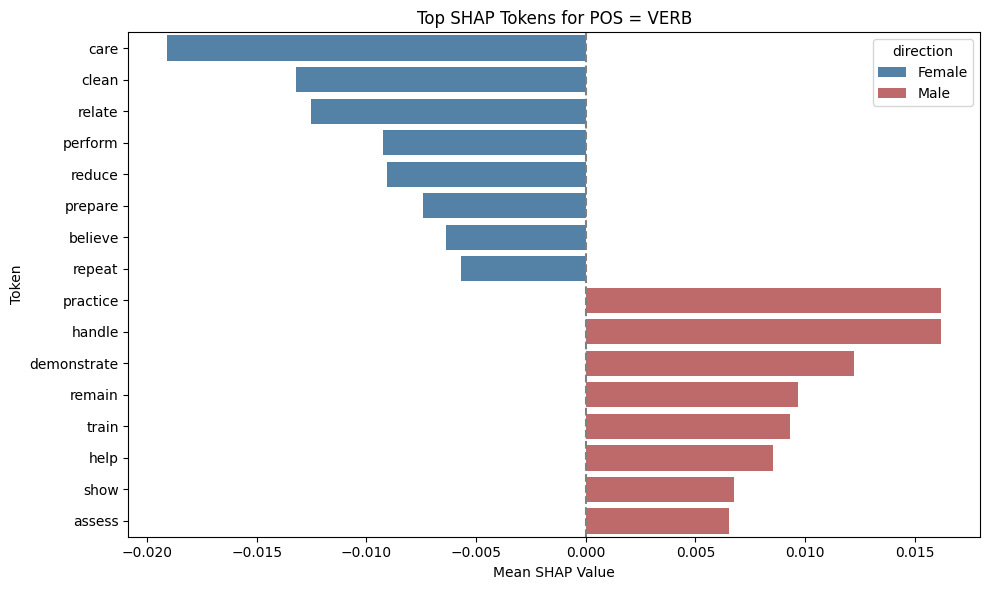

In [44]:
plot_top_shap_by_pos(df_shap, "ADJ", top_n=8)   # Adjectives
plot_top_shap_by_pos(df_shap, "NOUN", top_n=8)  # Nouns
plot_top_shap_by_pos(df_shap, "VERB", top_n=8)  # Verbs
